<a href="https://colab.research.google.com/github/DannielM/Data_Science/blob/main/DESAFIO.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Análise Exploratória dos Dados do Enem 2019**
Com base nos dados apresentados no link a seguir, vamos fazer uma análise exploratória desses dados.

Link: (https://docs.google.com/document/d/1y8qEHIeakRSB6ZCCcsvEDYOHzZcl9wJj5SZ1aXdch_o/edit?usp=sharing)

Arquivo - > ITENS_PROVA_2019 - ITENS_PROVA_2019.csv

In [51]:
# Importando as bibliotecas
# Por convensão vamos chamar o pandas de "pd"
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import requests
import folium
from plotly.offline import iplot
import scipy.stats as st 
 
#Informar o matplotlib inline sobre os gráficos
%matplotlib inline

# **O que é Análise Exploratória de Dados (EDA)?**
É uma forma de observar os dados afim de encontrar suas principais características e entender o que pode ser feito com elas.

Vale ressaltar que também é o momento onde podemos criar hipóteses sobre os dados e fazermos questionamentos ao conjunto de dados que estamos estudando, para saber como podemos encontrar as respostas dos questionamentos utilizando ferramentas adequadas.

In [2]:
# Vamos carregar o arquivo csv
# Lembre-se que o pandas vai converter o arquivo em um DataFrame
# Por convensão chamamos o DataFrame de "df"
# O arquivo nosso é separado por ";" por isso informamos o separador e a codificação necessária
df = pd.read_csv('/content/drive/My Drive/ITENS_PROVA_2019 - ITENS_PROVA_2019.csv', sep=';', encoding='cp1252')

# Vamos mostrar o DataFrame Completo
df

,CO_POSICAO,SG_AREA,CO_ITEM,TX_GABARITO,CO_HABILIDADE,TX_COR,CO_PROVA,TP_LINGUA,IN_ITEM_ADAPTADO
0,1,LC,55166,B,7,Azul,511,0.0,0
1,2,LC,54110,D,7,Azul,511,0.0,0
2,3,LC,23564,A,6,Azul,511,0.0,0
3,4,LC,31954,B,8,Azul,511,0.0,0
4,5,LC,118180,E,5,Azul,511,0.0,0
...,...,...,...,...,...,...,...,...,...
1940,176,MT,63359,B,9,Rosa,558,NaN,0
1941,177,MT,15171,D,25,Rosa,558,NaN,0
1942,178,MT,97573,E,10,Rosa,558,NaN,0
1943,179,MT,25163,D,25,Rosa,558,NaN,0


In [3]:
# Exibindo  somente as 5 primeiras linhas do DataFrame
df.head()

,CO_POSICAO,SG_AREA,CO_ITEM,TX_GABARITO,CO_HABILIDADE,TX_COR,CO_PROVA,TP_LINGUA,IN_ITEM_ADAPTADO
0,1,LC,55166,B,7,Azul,511,0.0,0
1,2,LC,54110,D,7,Azul,511,0.0,0
2,3,LC,23564,A,6,Azul,511,0.0,0
3,4,LC,31954,B,8,Azul,511,0.0,0
4,5,LC,118180,E,5,Azul,511,0.0,0


In [4]:
# Verificando o tamanho do DataFrame usando o comando "SHAPE"
# Formato do Shape é "(Linhas, Colunas)""
df.shape

(1945, 9)

In [5]:
# Verificando os tipos de dados das Colunas usando o camando "DTYPES"
df.dtypes

CO_POSICAO            int64
SG_AREA              object
CO_ITEM               int64
TX_GABARITO          object
CO_HABILIDADE         int64
TX_COR               object
CO_PROVA              int64
TP_LINGUA           float64
IN_ITEM_ADAPTADO      int64
dtype: object

In [6]:
# Verificando os tipos de dados usando o comando "INFO"
# É sempre bom fazer a verificação usando os dois comandos
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1945 entries, 0 to 1944
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   CO_POSICAO        1945 non-null   int64  
 1   SG_AREA           1945 non-null   object 
 2   CO_ITEM           1945 non-null   int64  
 3   TX_GABARITO       1945 non-null   object 
 4   CO_HABILIDADE     1945 non-null   int64  
 5   TX_COR            1945 non-null   object 
 6   CO_PROVA          1945 non-null   int64  
 7   TP_LINGUA         110 non-null    float64
 8   IN_ITEM_ADAPTADO  1945 non-null   int64  
dtypes: float64(1), int64(5), object(3)
memory usage: 136.9+ KB


In [7]:
# Vamos verificar a quantidade de itens que existem no arquivo
df.count()

CO_POSICAO          1945
SG_AREA             1945
CO_ITEM             1945
TX_GABARITO         1945
CO_HABILIDADE       1945
TX_COR              1945
CO_PROVA            1945
TP_LINGUA            110
IN_ITEM_ADAPTADO    1945
dtype: int64

In [8]:
# Fazendo uma análise Matemática das Colunas numéricas
# Obtendo assim, a "Média, Desvio Padrão, os valores Máximos e Mínimos e as variações percentuais em tornda média"
df.describe()

,CO_POSICAO,CO_ITEM,CO_HABILIDADE,CO_PROVA,TP_LINGUA,IN_ITEM_ADAPTADO
count,1945.000000,1945.000000,1945.000000,1945.000000,110.000000,1945.000000
mean,85.943445,76097.071979,14.981491,530.683805,0.500000,0.095116
std,53.111342,33731.599591,8.628219,19.750118,0.502288,0.293450
min,1.000000,6944.000000,1.000000,503.000000,0.000000,0.000000
25%,40.000000,47604.000000,7.000000,513.000000,0.000000,0.000000
50%,84.000000,84811.000000,15.000000,524.000000,0.500000,0.000000
75%,132.000000,97573.000000,23.000000,550.000000,1.000000,0.000000
max,180.000000,118306.000000,30.000000,565.000000,1.000000,1.000000


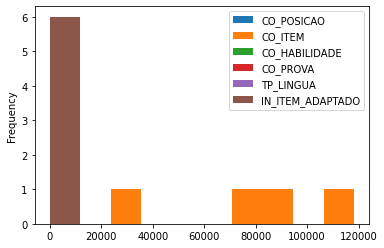

In [9]:
# Fazendo uma análise Matemática das Colunas numéricas
# Obtendo assim, a "Média, Desvio Padrão, os valores Máximos e Mínimos e as variações percentuais em tornda média"
df.describe('').plot.hist()

In [10]:
# Fazendo uma análise Matemática da Coluna "Habilidade"
df['CO_HABILIDADE'].describe()

count    1945.000000
mean       14.981491
std         8.628219
min         1.000000
25%         7.000000
50%        15.000000
75%        23.000000
max        30.000000
Name: CO_HABILIDADE, dtype: float64

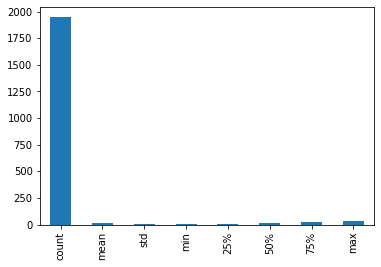

In [11]:
# Plotando a análise Matemática da Coluna "Habilidade"
df['CO_HABILIDADE'].describe().plot.bar()

In [12]:
# Analisando a coluna Habilidade para extrairmos as Habilidades mais cobradas no Enem 2019
# Organizando em função da maior quantidade
# Aqui comseguimos perceber quais as habilidades que mais forma cobradas e menos cobradas
df['CO_HABILIDADE'].value_counts(ascending=False)

8     89
23    86
16    85
7     80
15    78
1     76
6     74
3     73
17    73
20    72
11    69
28    69
2     68
27    68
4     67
24    65
21    64
5     64
26    63
12    62
14    62
18    61
9     58
25    56
19    56
30    54
10    43
22    42
29    37
13    31
Name: CO_HABILIDADE, dtype: int64

In [13]:
# Comparando a distribuição das Habilidades por Área
df.filter(items=['CO_HABILIDADE', 'SG_AREA']).groupby('CO_HABILIDADE').count().sort_values(by='SG_AREA', ascending=False).T

CO_HABILIDADE,8,23,16,7,15,1,6,17,3,20,28,11,2,27,4,24,5,21,26,14,12,18,9,25,19,30,10,22,29,13
SG_AREA,89,86,85,80,78,76,74,73,73,72,69,69,68,68,67,65,64,64,63,62,62,61,58,56,56,54,43,42,37,31


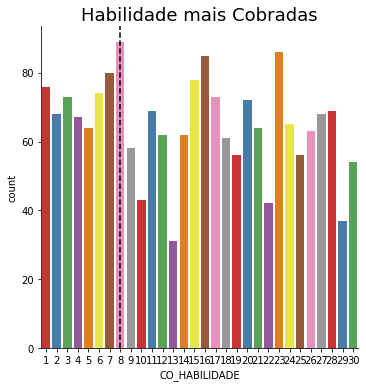

In [14]:
# Plotando em um gráfico as Habilidades mais cobradas no Enem 2019 para maior visibilidade
# Gráfico usando a biblioteca "SNS"
sns.catplot(x="CO_HABILIDADE", kind="count", palette="Set1", data=df)
plt.title('Habilidade mais Cobradas', fontsize=18)
plt.axvline(7.0, color='black', linestyle='--')

/usr/local/lib/python3.6/dist-packages/seaborn/distributions.py:2551: FutureWarning:

`distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).



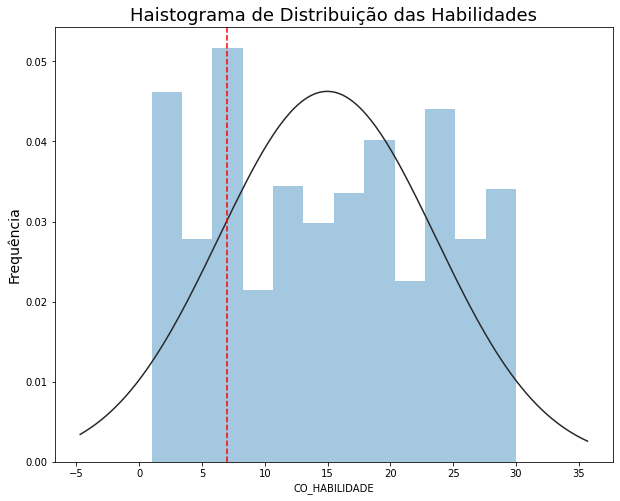

In [15]:
# Vamos plotar o Histograma das Habilidades e analisando a média em relação a uma Distribuição Gaussiana Normal
plt.figure(figsize=(10,8))
sns.distplot(df['CO_HABILIDADE'], fit=st.norm  , kde=False)
plt.title('Haistograma de Distribuição das Habilidades', fontsize=18)
plt.ylabel('Frequência', fontsize=14)
plt.axvline(7.0, color='red', linestyle='--')
plt.show()

Text(0, 0.5, 'Frequência')

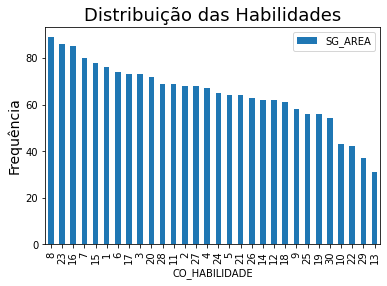

In [16]:
# Filtrando e agrupando as Habilidades por área tem-se:
# Plotando em um gráfico
df.filter(items=['CO_HABILIDADE', 'SG_AREA']).groupby('CO_HABILIDADE').count().sort_values(by='SG_AREA', ascending=False).plot.bar()

plt.title('Distribuição das Habilidades', fontsize=18)
plt.ylabel('Frequência', fontsize=14)

In [17]:
# Verificando as cores existentes no nosso DataFrame

df['TX_COR'].unique()

array(['Azul', 'Amarela', 'Rosa', 'Branca', 'Laranja', 'Verde', 'Cinza'],
      dtype=object)

In [18]:
# Fazendo a distribuição dos códigos das provas por Área
df.filter(items=['CO_PROVA', 'SG_AREA']).groupby('CO_PROVA').count().T

CO_PROVA,503,504,505,506,507,508,509,510,511,512,513,514,515,516,517,518,519,520,521,522,523,524,525,526,543,544,545,546,547,548,549,550,551,552,553,554,555,556,557,558,564,565
SG_AREA,45,45,45,45,45,45,45,45,50,50,50,50,45,45,45,45,45,45,50,45,45,45,50,45,45,45,45,45,45,45,45,45,50,50,50,50,45,45,45,45,45,50


In [19]:
# Com essa distribuição dos codigos das provas por Área 
# Conseguimos saber a frequência que elas aparecem por Área
# E depois soma-los para sabermos a quantidade
df.filter(items=['SG_AREA', 'CO_HABILIDADE']).groupby('SG_AREA').count()

,CO_HABILIDADE
SG_AREA,
CH,495
CN,450
LC,550
MT,450


Text(0.5, 1.0, 'Matriz de Referência')

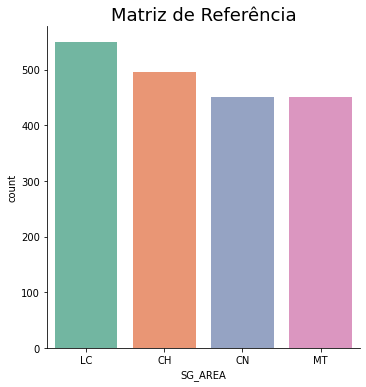

In [20]:
# Agrupando por área de Conchecimento
area = df.groupby('SG_AREA')

# Solicitando a soma das habilidades por cada área e agrupando-as
# Descubrindo assim, quais as matrizes mais cobradas no Enem 2019
sns.catplot(x="SG_AREA", kind="count", palette="Set2", data=df)
plt.title('Matriz de Referência', fontsize=18)

Text(0, 0.5, 'Frequência')

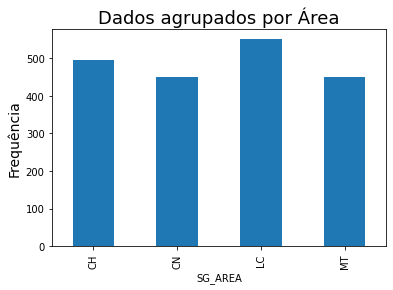

In [21]:
# Vamos plotar o gráfios das Matrizes do Enem agrupada
area['CO_HABILIDADE'].count().plot.bar()
plt.title('Dados agrupados por Área', fontsize=18)
plt.ylabel('Frequência', fontsize=14)

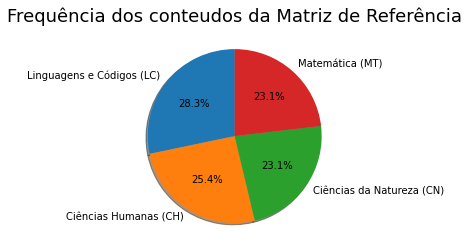

In [22]:
# Gráfico Pizza

# Criando o conjunto de dados
labels_lista = ['Linguagens e Códigos (LC)','Ciências Humanas (CH)', 'Ciências da Natureza (CN)', 'Matemática (MT)']
x_lista = [550, 495, 450, 450]

# Criando a representação
plt.axis('equal')
plt.pie(x_lista, labels=labels_lista, autopct='%1.1f%%', startangle=90, shadow=True)

# Gráfico em circulo
plt.title('Frequência dos conteudos da Matriz de Referência', fontsize=18)
plt.show()

<function matplotlib.pyplot.show>

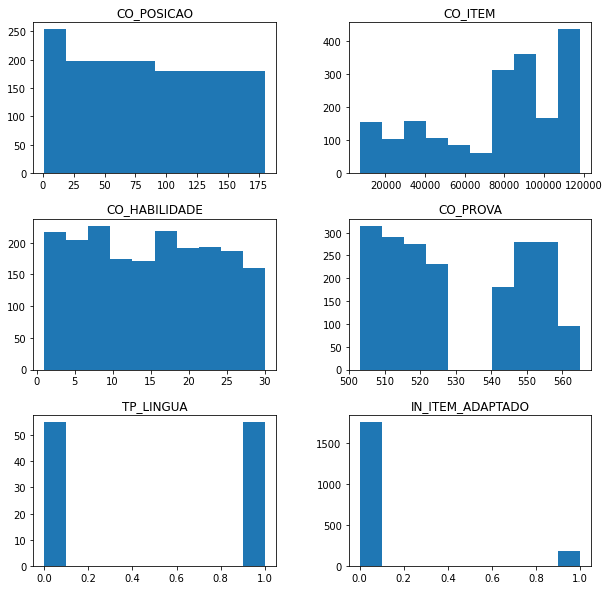

In [23]:
# Histograma dos intes do nosso DataFrame
df.hist(grid=False, figsize=(10,10), bins=10)
plt.show

# **Visualizando os dados utilizando o Boxplot**
Perceba que, para cada matriz conseguimos ver o limite inferior e superior, os quartis, a mediana, como os dados estão distribuídos e os valores que fogem da margem limite.

Text(0.5, 1.0, 'Gráfico de Boxplot das Matriz de Referência')

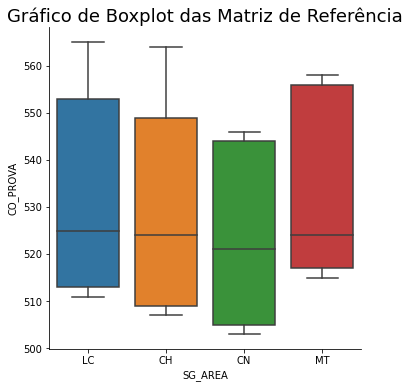

In [24]:
# Gráfico de Boxplot das Matriz em função das cores das provas
sns.catplot(x="SG_AREA", y="CO_PROVA", kind="box", data=df)
plt.title('Gráfico de Boxplot das Matriz de Referência', fontsize=18)

In [25]:
# Vamos criar um novo DataFrame e listar as a provas com o mesmo codigo
# Colocamos o comando "copy" para que ele não altere o DataFrame original
df_novo =df[df['CO_PROVA']==511].copy()
df_novo.value_counts()

CO_POSICAO  SG_AREA  CO_ITEM  TX_GABARITO  CO_HABILIDADE  TX_COR  CO_PROVA  TP_LINGUA  IN_ITEM_ADAPTADO
5           LC       118180   E            5              Azul    511       0.0        0                   1
                     48558    D            6              Azul    511       1.0        0                   1
4           LC       118167   A            8              Azul    511       1.0        0                   1
                     31954    B            8              Azul    511       0.0        0                   1
3           LC       39016    C            7              Azul    511       1.0        0                   1
                     23564    A            6              Azul    511       0.0        0                   1
2           LC       118222   B            5              Azul    511       1.0        0                   1
                     54110    D            7              Azul    511       0.0        0                   1
1           LC       967

In [26]:
# Vamos criar um novo DataFrame e listar as a provas com o mesma habilidades
# Colocamos o comando "copy" para que ele não altere o DataFrame original
df_novo =df[df['CO_HABILIDADE']==8].copy()
df_novo.value_counts()

CO_POSICAO  SG_AREA  CO_ITEM  TX_GABARITO  CO_HABILIDADE  TX_COR   CO_PROVA  TP_LINGUA  IN_ITEM_ADAPTADO
5           LC       118167   A            8              Verde    525       1.0        1                   1
                                                          Laranja  521       1.0        0                   1
1           LC       31954    B            8              Laranja  521       0.0        0                   1
                                                          Verde    525       0.0        1                   1
                     96705    A            8              Azul     511       1.0        0                   1
2           LC       31954    B            8              Branca   514       0.0        0                   1
                     32839    B            8              Amarela  552       1.0        0                   1
                     96705    A            8              Branca   514       1.0        0                   1
               

Text(0.5, 1.0, 'Quantidades de Cores por Prova')

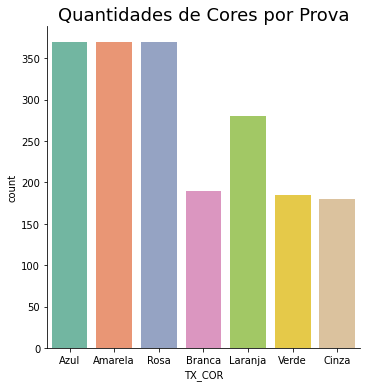

In [27]:
# Verificando a quantidade das cores das provas cobradas
sns.catplot(x="TX_COR", kind="count", palette="Set2", data=df)
plt.title('Quantidades de Cores por Prova', fontsize=18)

## ***Quais foram as Matrizes mais cobradas no Enem 2019?***

Segundo as análises realizadas percebemos que as Matrizes mais cobradas foram:

- ***Matriz de Referência de Linguagens, Códigos e suas Tecnologias***

- ***Matriz de Referência de Ciências Humanas e suas Tecnologias***

E as demais foram cobradas na mesma proporção. 


## **Quais foram as Habilidades mais cobradas?**
Segundo as análises realizadas percebemos que as Habilidades mais cobradas foram:

- H8 (LC): ***Reconhecer a importância da produção cultural em LEM como representação da diversidade cultural e linguística.***

- H8 (CH): ***Analisar a ação dos estados nacionais no que se refere à dinâmica dos fluxos populacionais e no enfrentamento de problemas de ordem econômico-social.***

- H23 (LC):***Inferir em um texto quais são os objetivos de seu produtor e quem é seu público alvo, pela análise dos procedimentos argumentativos utilizados.***

- H23 (CH):***Analisar a importância dos valores éticos na estruturação política das sociedades.***

- H16 (LC):***Relacionar informações sobre concepções artísticas e procedimentos de construção do texto literário.***

- H16 (CH): ***Identificar registros sobre o papel das técnicas e tecnologias na organização do trabalho e/ou da vida social. ***